# 贝叶斯线性回归

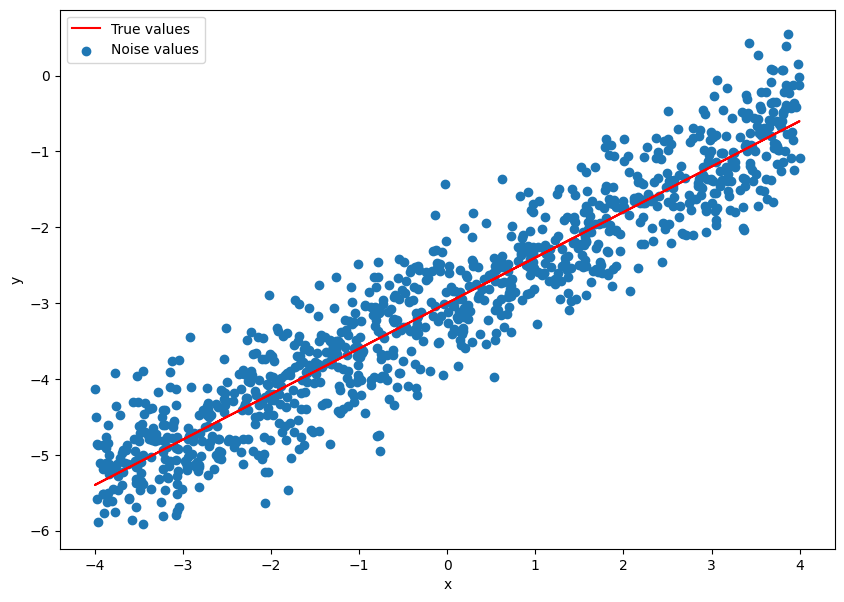

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

np.random.seed(0)

beta0 = -3
beta1 = 0.6

def prepair_data(noise_std_dev, data):
    
    n_samples = len(data)
    if noise_std_dev == 0:
        return beta1 * data + beta0
    else:
        return beta1 * data + beta0 + np.random.normal(0, noise_std_dev, n_samples)


n_datapoints = 1000

noise_std = 0.5
noise_var = noise_std**2
lower_bound = -4
upper_bound = 4

x_vals = np.random.uniform(lower_bound, upper_bound, n_datapoints)
y_vals = prepair_data(0., x_vals)
y_vals_noise = prepair_data(noise_std, x_vals)

plt.figure(figsize=(10,7))
plt.plot(x_vals, y_vals, color='r', label="True values")
plt.scatter(x_vals, y_vals_noise, label="Noise values")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()


In [3]:
from scipy.stats import multivariate_normal
from scipy.stats import norm
import numpy as np

class BayesianLinearRegression:
    def __init__(self, prior_mean, prior_cov, noise_var):
        self.prior_mean = prior_mean[:, np.newaxis]
        self.prior_cov = prior_cov
        self.prior = multivariate_normal(prior_mean, prior_cov)

        self.noise_var = noise_var
        self.noise_precision = 1 / noise_var

        self.param_posterior = self.prior
        self.post_mean = self.prior_mean
        self.post_cov = self.prior_cov

    def update_posterior(self, x_vals, targets):
        targets = targets[:, np.newaxis]
        
        X = self.compute_design_matrix(x_vals)

        X2 = X.T.dot(X)
        inv_prior_cov = np.linalg.inv(self.prior_cov)
        self.post_cov = np.linalg.inv(inv_prior_cov + self.noise_precision * X2)
        self.post_mean = self.post_cov.dot(inv_prior_cov.dot(self.prior_mean) + self.noise_precision * X.T.dot(targets))

        self.param_posterior = multivariate_normal(self.post_mean.flatten(), self.post_cov)

    def compute_design_matrix(self, features):
        n_samples = len(features)
        phi_0 = np.ones(n_samples)
        design_matrix = np.stack((phi_0, features), axis=1)
        return design_matrix


    def predict(self, features):
        X = self.compute_design_matrix(features)

        pred_mean = X.dot(self.post_mean) # m * 1, m: num of examples
        pred_cov = X.dot(self.post_cov.dot(X.T)) + self.noise_var # m*m, m: num of examples

        pred_posterior = norm(loc=pred_mean.flatten(), scale=pred_cov**0.5) # m变量的正态分布，就是针对m个输入，都会有一个正态分布的输出
        return pred_posterior



def plot_param_posterior(lower_bound, upper_bound, model):
    fig = plt.figure()
    mesh_features, mesh_labels = np.mgrid[lower_bound:upper_bound:.01, lower_bound:upper_bound:.01]

    pos = np.dstack((mesh_features, mesh_labels))
    plt.figure(figsize=(8, 8))
    plt.contourf(mesh_features, mesh_labels, model.param_posterior.pdf(pos), levels=15)
    plt.scatter(beta0, beta1, color='red')
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)


mean: [-1.7044174  -0.66558868], var: [[ 0.1974275  -0.11815699]
 [-0.11815699  0.45385875]]
mean: [-2.46972507  0.46544349], var: [[ 0.07422244 -0.03665083]
 [-0.03665083  0.07196077]]
mean: [-3.00782451  0.61707577], var: [[ 0.06458924 -0.0159968 ]
 [-0.0159968   0.01337348]]
mean: [-2.96684543  0.5767145 ], var: [[ 0.00619818 -0.00017325]
 [-0.00017325  0.00118427]]
mean: [-3.01019502  0.57899315], var: [[0.00544931 0.00068172]
 [0.00068172 0.00093169]]
mean: [-2.94960224  0.56899446], var: [[ 0.00251303 -0.00011392]
 [-0.00011392  0.00050962]]
mean: [-2.95027258  0.61175424], var: [[8.32282837e-04 7.05751307e-06]
 [7.05751307e-06 1.48203767e-04]]
mean: [-2.99580424  0.58862509], var: [[4.99634856e-04 3.53583956e-06]
 [3.53583956e-06 9.30518789e-05]]


<Figure size 640x480 with 0 Axes>

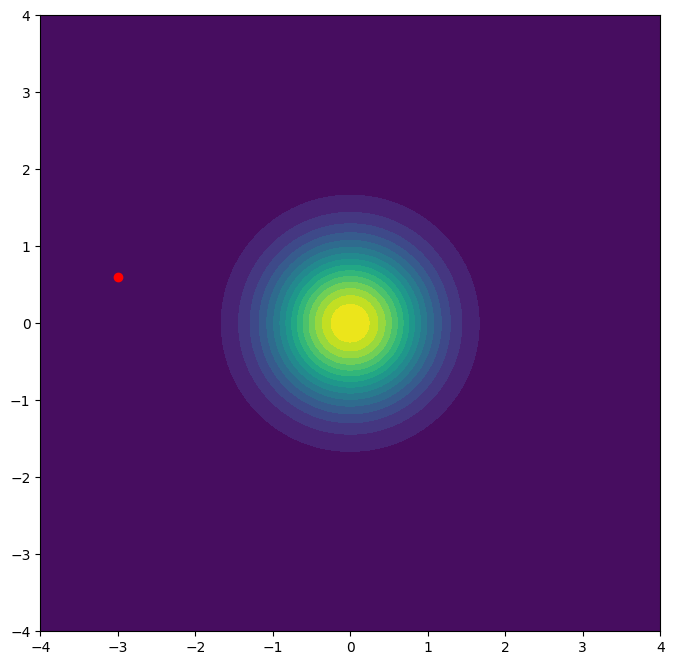

<Figure size 640x480 with 0 Axes>

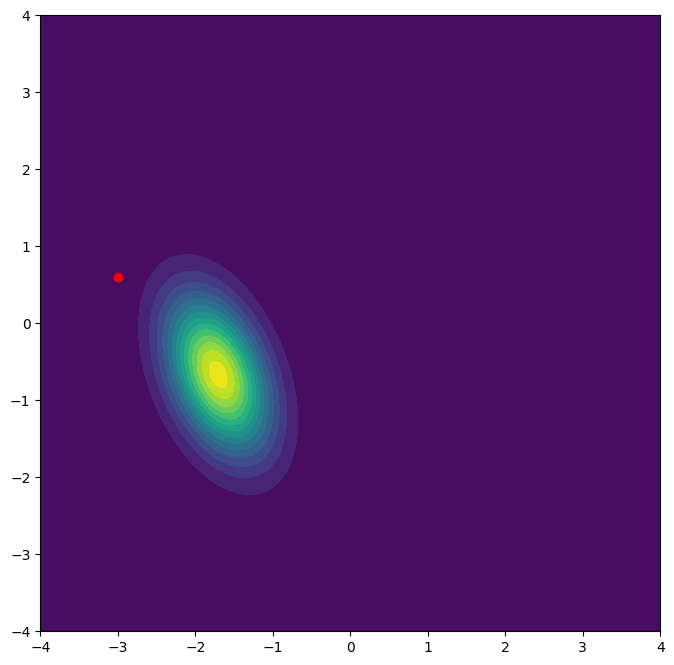

<Figure size 640x480 with 0 Axes>

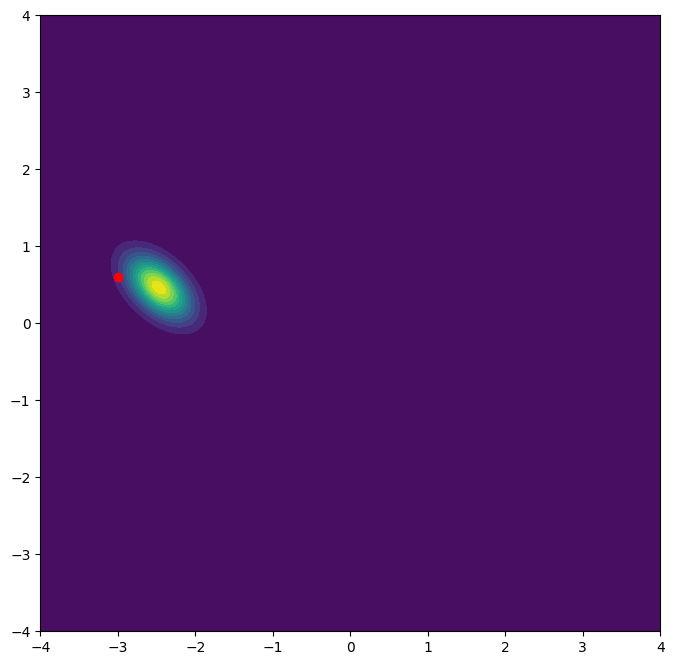

<Figure size 640x480 with 0 Axes>

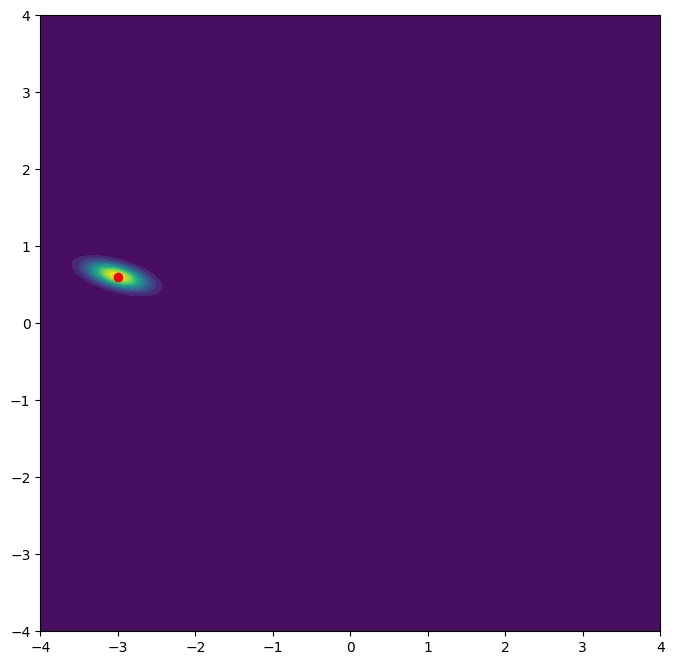

<Figure size 640x480 with 0 Axes>

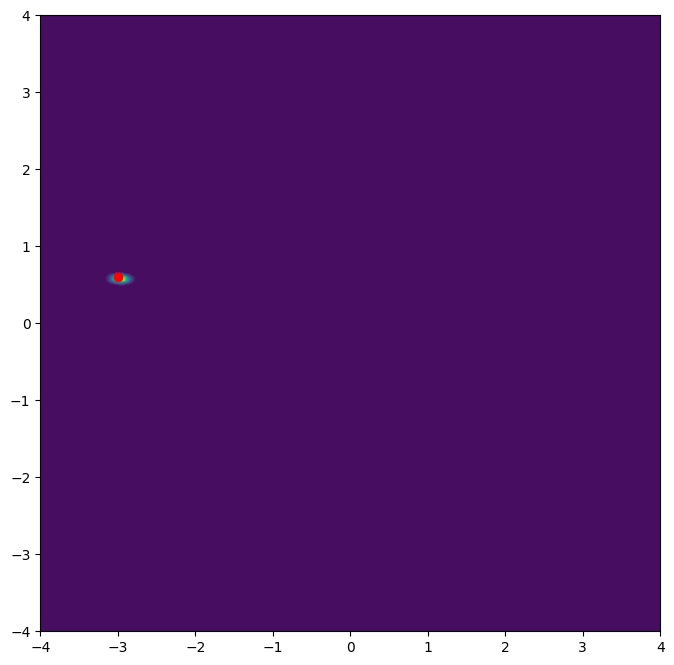

<Figure size 640x480 with 0 Axes>

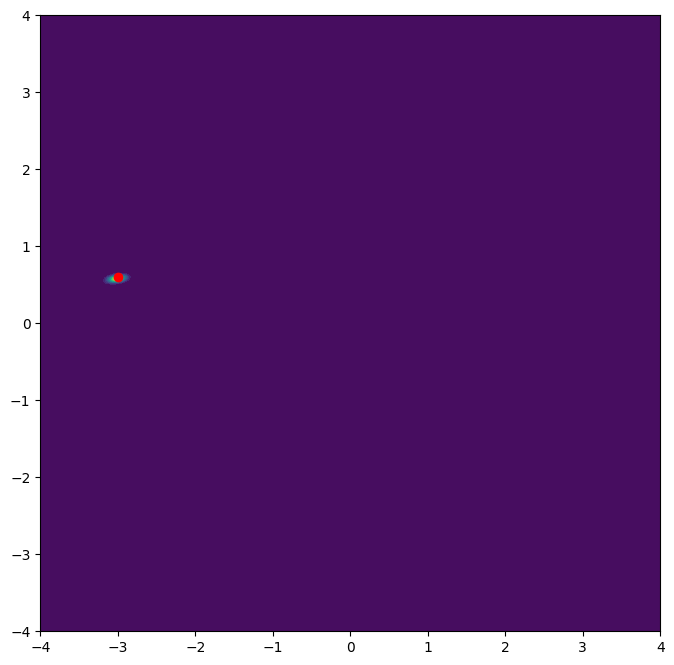

<Figure size 640x480 with 0 Axes>

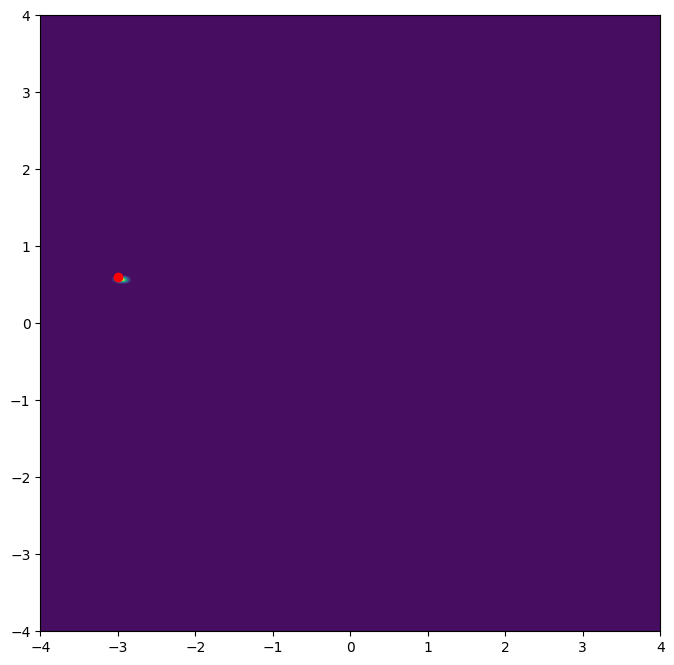

<Figure size 640x480 with 0 Axes>

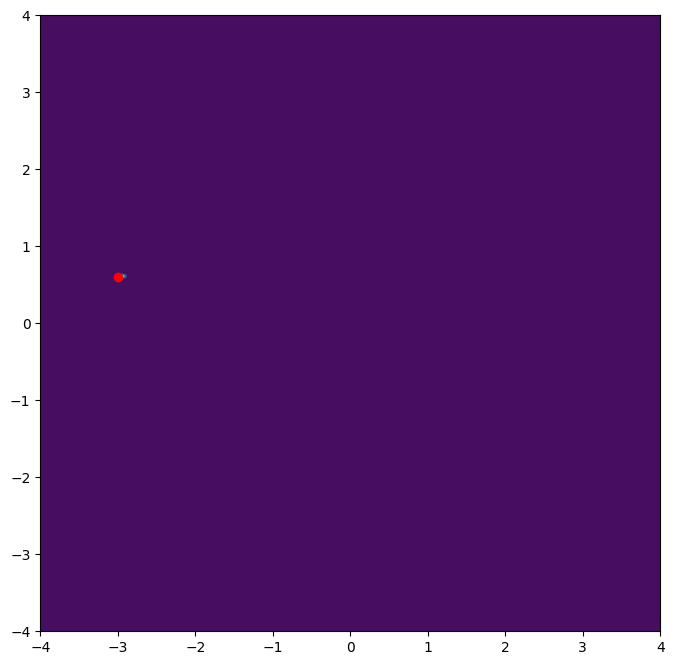

<Figure size 640x480 with 0 Axes>

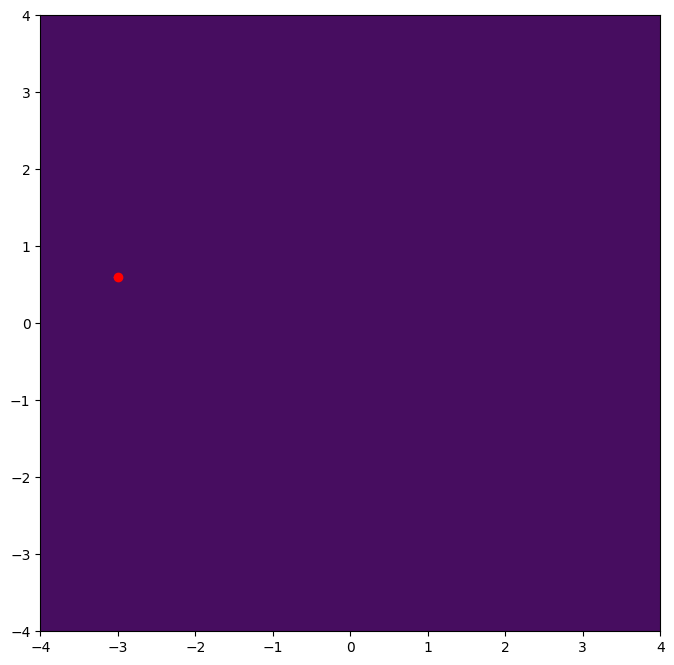

In [4]:
prior_mean = np.array([0, 0])
prior_cov = np.array([
    [0.5, 0],
    [0,   0.5]
])

model = BayesianLinearRegression(prior_mean, prior_cov, noise_var)


plot_param_posterior(lower_bound, upper_bound, model)

n_points_lst = [1, 5, 10, 50, 100, 200, 500, 1000]
previous_n_points = 0
for n_points in n_points_lst:
    x_train = x_vals[previous_n_points:n_points]
    y_train = y_vals_noise[previous_n_points:n_points]

    model.update_posterior(x_train, y_train)
    print(f'mean: {model.param_posterior.mean}, var: {model.param_posterior.cov}')

    plot_param_posterior(lower_bound,
                         upper_bound,
                         model)

    previous_n_points = n_points

In [5]:
x = 1
y = prepair_data(0, np.array([x]))
prediction = model.predict(np.array([x]))
print(prediction.mean(), prediction.std(), y)

[[-2.40717915]] [[0.5005994]] [-2.4]
